# Solveit Widgets

> Adds interactive widgets to solveit

The core idea of SolveIt widgets that makes it different from ipywidgets the state is in the python kernel. And we re-use the SolveIt logic for updating the page by either re-running a (code) msg, or by doing a out-of-band swap.

In [ ]:
#| default_exp widgets

In [ ]:
#| export
from fastcore.utils import *
from fastcore.parallel import bg_task
from pyskills import allow
from fasthtml.common import *
from monsterui.all import Range
from dialoghelper.core import pop_data_a, add_html, call_endp, dh_settings
import uuid,io,base64,httpx,os,json
from PIL import Image

## Widget

In [ ]:
#| export
class Widget:
    "Kernel-resident interactive widget; subclasses define `render` and `handle`"
    def __init__(self, state=None): self.id,self.state,self.task,self.oob_views,self.rerun_ids,self.oob_busy,self.oob_pending,self.rerun_busy,self.rerun_pending = 'w_'+uuid.uuid4().hex[:8],state,None,{},set(),False,False,False,False

Every widget gets a unique `id` (used as its root element id so updates can target it) and holds its `state` as a plain attribute. The other fields are bookkeeping for the out-of-band views, rerun message ids, and the coalescing flags we'll meet shortly:

In [ ]:
w = Widget(10)
w.id, w.state

('w_b7006fc8', 10)

**Browser → Python.** `bind()` builds the JS for an element's event handler: it reads a property, throttles to roughly one message per `ms` milliseconds, and calls `pushData(id, {...})`, which delivers the value to the kernel keyed by this widget's id:

In [ ]:
#| export
@patch
def bind(self:Widget, data_key='val', dom_prop='value', ms=50, **kw):
    fixed = ''.join(f"{k}:{v!r}," for k,v in kw.items())
    push = f"pushData('{self.id}', {{{fixed}{data_key}:v}})"
    return (f"var v=this.{dom_prop},e=this,n=Date.now();clearTimeout(e._tt);"
            f"if(n-(e._lt||0)>{ms}){{e._lt=n;{push};}}"
            f"else e._tt=setTimeout(function(){{e._lt=Date.now();{push};}},{ms});")

That returns a plain JS string we drop into an `oninput` (or any) handler:

In [ ]:
print(Widget(0).bind())

var v=this.value,e=this,n=Date.now();clearTimeout(e._tt);if(n-(e._lt||0)>50){e._lt=n;pushData('w_e9c5f9dd', {val:v});}else e._tt=setTimeout(function(){e._lt=Date.now();pushData('w_e9c5f9dd', {val:v});},50);


A base `Widget` does not yet know what HTML it should show or how to respond to events. A concrete subclass provides those parts.

In [ ]:
#| export
@patch
def render(self:Widget): raise NotImplementedError
@patch
def handle(self:Widget, data): raise NotImplementedError

Here's a minimal `Slider` demo. Its `render` method returns a range input plus a text label, and its `handle` method stores the incoming value in `self.state`. See how it uses `oninput=self.bind()` to send updates to the Python kernel via `pushData`; later we'll see how those updates are routed back to this widget's `handle` method:

In [ ]:
class Slider(Widget):
    def __init__(self, val=0., min=0., max=100.):
        self.min,self.max = min,max
        super().__init__(val)
    def render(self):
        return Div(Input(type='range', min=self.min, max=self.max, value=self.state,
                         oninput="this.nextElementSibling.textContent=this.value;"+self.bind()),
                   Span(self.state), id=self.id)
    def handle(self, data): self.state = float(data['val'])

Let's inspect what `render()` actually returns. We wrap it in `to_xml` to see the raw HTML contents.

In [ ]:
to_xml(Slider(50).render())

'<div id="w_a95be0af">\n  <input type="range" min="0.0" max="100.0" value="50" oninput="this.nextElementSibling.textContent=this.value;var v=this.value,e=this,n=Date.now();clearTimeout(e._tt);if(n-(e._lt||0)&gt;50){e._lt=n;pushData(\'w_a95be0af\', {val:v});}else e._tt=setTimeout(function(){e._lt=Date.now();pushData(\'w_a95be0af\', {val:v});},50);">\n<span>50</span></div>\n'

Once we have a concrete widget like `Slider`, we can add the fast update path.

`refresh_oob_views` is the method that repaints any registered out-of-band views. It loops over `self.oob_views` and swaps each one out-of-band, so the browser only replaces that one element.

In [ ]:
#| export
@patch
async def refresh_oob_views(self:Widget):
    if self.oob_busy:
        self.oob_pending=True
        return
    self.oob_busy,self.oob_pending = True,False
    try:
        for vid,draw in self.oob_views.items(): add_html(Div(draw(), id=vid, hx_swap_oob='true'))
    finally: self.oob_busy = False
    if self.oob_pending: await self.refresh_oob_views()

In [ ]:
#| export
def oob_view(draw, *ws):
    "Shared out-of-band view repainted by any of `ws`"
    vid = 'v_'+uuid.uuid4().hex[:8]
    for w in ws: w.oob_views = {k:v for k,v in w.oob_views.items() if v is not draw}; w.oob_views[vid] = draw
    return Div(draw(), id=vid)


`busy` and `pending` are just coalescing flags: if a new drag arrives while a repaint is already in flight, we remember that something changed and repaint once more at the end, using the latest state.

The other update path is message re-running.

`live()` accesses the state and marks the current message for rerun. `rerun_msgs()` re-runs every registered message through the normal run queue, so downstream Python code gets recomputed too.

In [ ]:
#| export
def current_msg_id(): return call_endp('read_msg_', json=True, n=0)['id']

In [ ]:
#| export
@patch
def live(self:Widget):
    self.rerun_ids.add(current_msg_id())
    return self.state

We dont want to focus the selection of a msg whenever it gets updated by a widget. So we use this little wrapper function to queietly trigger the rerun and ignore the select message logic.

In [ ]:
#| export
async def run_msg_quiet(ids, dname=None, timeout=5):
    dname = dname or __dialog_name
    data = dict(ids=ids, dlg_name=dname.strip('/'))
    async with httpx.AsyncClient() as c:
        await c.post(f'http://localhost:{dh_settings["port"]}/add_runq_', data=data, headers={'Accept':'application/json'}, timeout=timeout)

In [ ]:
#| export
@patch
async def rerun_msgs(self:Widget):
    if self.rerun_busy: self.rerun_pending=True; return
    self.rerun_busy,self.rerun_pending = True,False
    try:
        for msg_id in self.rerun_ids: await run_msg_quiet(msg_id)
    finally: self.rerun_busy = False
    if self.rerun_pending: await self.rerun_msgs()

This path is more flexible, but heavier than `refresh_oob_views`: whole messages run again rather than a single DOM node being swapped.

`_listen()` waits for the next browser event for this widget, applies it with `handle`, then kicks off both update paths. The two sides pair up through a per-widget channel: `pushData(id, …)` in the browser enqueues a value keyed by the widget's `id`, and `await pop_data_a(self.id)` here pops the next one off, blocking until it arrives.

In [ ]:
#| export
@patch
async def _listen(self:Widget):
    while True:
        d = await pop_data_a(self.id)
        if d.get('js_status')=='timeout': continue
        try:
            self.handle(d)
            bg_task(self.refresh_oob_views())
            bg_task(self.rerun_msgs())
        except Exception as e: print('handle err', e)

`_ft()` is the moment the widget becomes live. The first time it renders, it starts `_listen()` in the background. `__ft__` and `_repr_html_` let us return the widget straight from a message.

the `event.stopPropgataion()` bit is there to avoid selecting the current message when interacting with a widget, so you can interact with it more smoothly.

In [ ]:
#| export
@patch
def _ft(self:Widget):
    if not self.task: self.task = bg_task(self._listen())
    ft = self.render()
    ft.attrs['onclick'] = 'event.stopPropagation()'
    return ft
@patch
def __ft__(self:Widget): return self._ft()
@patch
def _repr_html_(self:Widget): return to_xml(self._ft())

Now we can see the fast path in action. First render a slider, then register a tiny text view with `oob_view`. Dragging updates the text smoothly because only that one element gets swapped.

In [ ]:
sl = Slider(50)
sl

In [ ]:
def draw_val(): return Span(f'state={sl.state}')
oob_view(draw_val, sl)

<div id="v_d30d21cb"><span>state=50</span></div>

Now the heavy path. `sl.live()` registers this message for rerun, so every drag re-executes it and prints the latest value.

In [ ]:
state = sl.live()
print(f'{state=}')

state=80.0


At this point you can compare the two paths directly: the `oob_view` text above should feel smooth, while the message below visibly re-runs.

`update(**d)` drives a widget from Python as if the browser had sent an event: it `handle`s the data, oob-swaps its own render, then refreshes out-of-band views and rerun messages.

In [ ]:
#| export
@patch
async def update(self:Widget, **d):
    self.handle(d)
    ft = self.render()
    ft.attrs['hx_swap_oob'] = 'true'
    add_html(ft)
    await self.refresh_oob_views()
    await self.rerun_msgs()

In [ ]:
await sl.update(val=80)

You can use this to ask the AI to update a widget using pyrun.

In [ ]:
#| export
allow({Widget:...})

## Numeric Widgets

In [ ]:
#| export
class MonsterRangeBase(Widget):
    def __init__(self, val, min=0, max=100, step=1):
        self.min,self.max,self.step = min,max,step
        super().__init__(val)
    def _val_str(self): return str(self.state)
    def _parse(self, s): return float(s)
    def render(self):
        js = f"document.getElementById('{self.id}').addEventListener('uk-input-range:input',function(){{{self.bind()}}});"
        return Div(Range(value=self._val_str(), min=self.min, max=self.max, step=self.step, label=True, id=self.id),
                   Script(js), id=self.id+'_wrap', style='max-width:16rem;padding-top:0.5rem;padding-left:0.5rem')
    def handle(self, data): self.state = self._parse(data['val'])

In [ ]:
#| export
class IntSlider(MonsterRangeBase):
    def __init__(self, val=0, min=0, max=100, step=1): super().__init__(val, min, max, step)
    def _parse(self, s): return int(float(s))

In [ ]:
#| export
isl = IntSlider()
isl

In [ ]:
isl.state

0

In [ ]:
#| export
class FloatSlider(MonsterRangeBase):
    def __init__(self, val=0., min=0., max=100., step=0.1): super().__init__(val, min, max, step)

In [ ]:
#| export
fsl = FloatSlider()
fsl

In [ ]:
fsl.state

0.0

In [ ]:
#| export
class IntRangeSlider(MonsterRangeBase):
    def __init__(self, val=(0,100), min=0, max=100, step=1): super().__init__(list(val), min, max, step)
    def _val_str(self): return f'{self.state[0]},{self.state[1]}'
    def _parse(self, s): return [int(float(x)) for x in str(s).split(',')]

In [ ]:
#| export
irs = IntRangeSlider()
irs

In [ ]:
irs.state

[0, 100]

In [ ]:
#| export
class FloatRangeSlider(MonsterRangeBase):
    def __init__(self, val=(0.,100.), min=0., max=100., step=0.1): super().__init__(list(val), min, max, step)
    def _val_str(self): return f'{self.state[0]},{self.state[1]}'
    def _parse(self, s): return [float(x) for x in str(s).split(',')]

In [ ]:
#| export
frs = FloatRangeSlider()
frs

In [ ]:
frs.state

[0.0, 100.0]

## ExcalidrawWidget

The ExcalidrawWidget is useful for drawing inside SolveIt. It works especially well when the AI can adjust it too using `pyrun`, the widget's code output renders some hidden output only visible to the AI that explains which methods to use in `tip`.

In [ ]:
#| export
class ExcalidrawWidget(Widget):
    def __init__(self, scene=None, h=650): self.h = h; super().__init__(scene or dict(elements=[], appState={}, files={}))
    def _plain(self, o):
        if isinstance(o, dict): return {k:self._plain(v) for k,v in o.items()}
        if isinstance(o, (list,tuple,L)): return [self._plain(v) for v in o]
        return o
    def handle(self, d):
        scene = self._plain(d.get('scene', {}))
        self.state = dict(elements=scene.get('elements', []), appState=scene.get('appState', {}), files=scene.get('files', {}), image_base64=d.get('image_base64', self.state.get('image_base64', '')))
    
    def render(self):
        scene,host = json.dumps(dict(elements=self._plain(self.state.get('elements', [])), appState=self._plain(self.state.get('appState', {})), files=self._plain(self.state.get('files', {})))),f'{self.id}_host'
        inbox = f'{self.id}_inbox'
        css = '.excalidraw .default-sidebar-trigger,.excalidraw [data-testid="main-menu-trigger"],.excalidraw .main-menu-trigger,.excalidraw [data-testid="toolbar-more-tools"],.excalidraw .App-toolbar__extra-tools-trigger{display:none!important;}'
        tips = 'AI tips: use self.get_pil() to inspect the canvas; use self.state to inspect raw scene coordinates; use self.add(...) to add elements.'
        js = f"""\
import * as ExcalidrawLib from "https://esm.sh/@excalidraw/excalidraw@0.18.0?deps=react@18.2.0,react-dom@18.2.0";
import React from "https://esm.sh/react@18.2.0";
import ReactDOM from "https://esm.sh/react-dom@18.2.0/client";
window.EXCALIDRAW_ASSET_PATH = "https://esm.sh/@excalidraw/excalidraw@0.18.0/dist/prod/";
window._xw = window._xw||{{}};
let el = document.getElementById("{host}");
if (!el.dataset.mounted) {{
  let root = ReactDOM.createRoot(el), to_data = b => new Promise(r => {{ let fr = new FileReader(); fr.onloadend = () => r(fr.result); fr.readAsDataURL(b); }});
  let onChange = async (elements, appState, files) => {{
    let scene = {{elements, appState, files}}, image_base64 = "";
    if (elements.length) try {{ image_base64 = await to_data(await ExcalidrawLib.exportToBlob({{elements, appState, files, mimeType:"image/png"}})); }} catch {{}}
    pushData("{self.id}", {{scene, image_base64}});
  }};
  root.render(React.createElement("div", {{style:{{height:"{self.h}px"}}}}, React.createElement(ExcalidrawLib.Excalidraw, {{initialData:{scene}, onChange, excalidrawAPI:api => window._xw["{self.id}"] = api}})));
  let ib = document.getElementById("{inbox}");
  new MutationObserver(() => {{
    let t = ib.textContent.trim(); if (!t) return; ib.textContent = "";
    let api = window._xw["{self.id}"]; if (!api) return;
    let add = ExcalidrawLib.convertToExcalidrawElements(JSON.parse(t));
    api.updateScene({{elements:[...api.getSceneElements(), ...add]}});
    if (api.scrollToContent) api.scrollToContent(add);
  }}).observe(ib, {{childList:true, characterData:true, subtree:true}});
  el.dataset.mounted = 1;
}}
"""
        return Div(Style(css), Link(rel='stylesheet', href='https://esm.sh/@excalidraw/excalidraw@0.18.0/dist/dev/index.css'), Pre(tips, style='display:none'), Div(id=host), Div(id=inbox, style='display:none'), Script(js, type='module'), id=self.id)
    
    def add(self, *els):
      "Expects dicts as defined in: https://raw.githubusercontent.com/excalidraw/excalidraw/refs/heads/master/dev-docs/docs/%40excalidraw/excalidraw/api/excalidraw-element-skeleton.mdx"
      add_html(Div(json.dumps(list(els)), id=self.id+'_inbox', hx_swap_oob='innerHTML'))

    def get_pil(self):
        img = self.state.get('image_base64', '')
        if not img: return None
        return Image.open(io.BytesIO(base64.b64decode(img.split(',', 1)[-1])))

In [ ]:
# not allowed in general because add is unsafe and can run random js
allow({ExcalidrawWidget:...})

In [ ]:
xw = ExcalidrawWidget()
xw

The great thing about excalidraw is that you and the ai can draw together but for testing purposes we'll just do things programmatically.

add shape

In [ ]:
xw.add(dict(type='ellipse', x=600, y=430, width=130, height=95, strokeColor='#2f9e44', strokeWidth=4))

get img

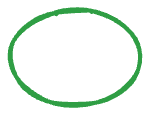

In [ ]:
xw.get_pil()

get state

In [ ]:
xw.state.keys()

dict_keys(['elements', 'appState', 'files', 'image_base64'])

In [ ]:
len(xw.state['elements'])==1

True

finish the drawing and make it into a big green dog using your python tool.